# OLAP Data Analysis
**ShipmentSure — Predicting On-Time Delivery**

OLAP-style slice and dice analysis:
- Boolean filtering for specific operational scenarios
- Roll-up and drill-down metric aggregation
- Multi-dimensional heatmaps for stakeholder interpretation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv('../data/Train.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,C,Flight,2,5,306,6,high,M,45,3838,1
1,2,F,Ship,7,2,114,3,high,M,35,2710,1
2,3,B,Ship,7,2,215,7,medium,F,44,4152,0
3,4,A,Road,5,3,126,5,medium,M,54,2245,0
4,5,F,Ship,3,5,113,3,medium,M,43,1806,1


In [3]:
# OLAP Dice: Slice by Flight shipments only
flight_df = df[df['Mode_of_Shipment'] == 'Flight']
print(f"Flight shipments: {len(flight_df)}")
print(f"On-time rate (Flight): {flight_df['Reached.on.Time_Y.N'].mean():.2%}")

Flight shipments: 322
On-time rate (Flight): 45.96%


In [4]:
# Dice: High-importance products with high discount (>50)
high_discount_high_imp = df[
    (df['Product_importance'] == 'high') & (df['Discount_offered'] > 50)
]
print(f"High importance + High discount shipments: {len(high_discount_high_imp)}")
print(f"On-time rate: {high_discount_high_imp['Reached.on.Time_Y.N'].mean():.2%}")

High importance + High discount shipments: 65
On-time rate: 49.23%


In [5]:
# Roll-up: Overall on-time summary by Warehouse Block + Mode
rollup = df.groupby(['Warehouse_block', 'Mode_of_Shipment']).agg(
    Total_Shipments=('Reached.on.Time_Y.N', 'count'),
    On_Time_Count=('Reached.on.Time_Y.N', 'sum'),
    On_Time_Rate=('Reached.on.Time_Y.N', 'mean'),
    Avg_Cost=('Cost_of_the_Product', 'mean'),
    Avg_Discount=('Discount_offered', 'mean')
).round(3).reset_index()
print("Roll-up summary (Warehouse + Mode):")
rollup

Roll-up summary (Warehouse + Mode):


,Warehouse_block,Mode_of_Shipment,Total_Shipments,On_Time_Count,On_Time_Rate,Avg_Cost,Avg_Discount
0,A,Flight,52,24,0.462,200.038,33.538
1,A,Road,63,38,0.603,193.000,28.127
2,A,Ship,82,50,0.610,210.841,32.707
3,B,Flight,60,28,0.467,198.150,28.817
4,B,Road,65,37,0.569,200.154,33.615
5,B,Ship,55,24,0.436,219.327,29.273
6,C,Flight,68,32,0.471,198.588,33.912
7,C,Road,77,43,0.558,203.065,33.325
8,C,Ship,69,37,0.536,189.870,30.377
9,D,Flight,69,31,0.449,199.072,27.174


In [6]:
# Pivot: Product importance x Gender x On-time rate
pivot1 = df.pivot_table(
    values='Reached.on.Time_Y.N',
    index='Product_importance',
    columns='Gender',
    aggfunc='mean'
).round(3)
print("Pivot: Product Importance x Gender x On-Time Rate:")
pivot1

Pivot: Product Importance x Gender x On-Time Rate:


Gender,F,M
Product_importance,,
high,0.522,0.542
low,0.511,0.509
medium,0.455,0.491


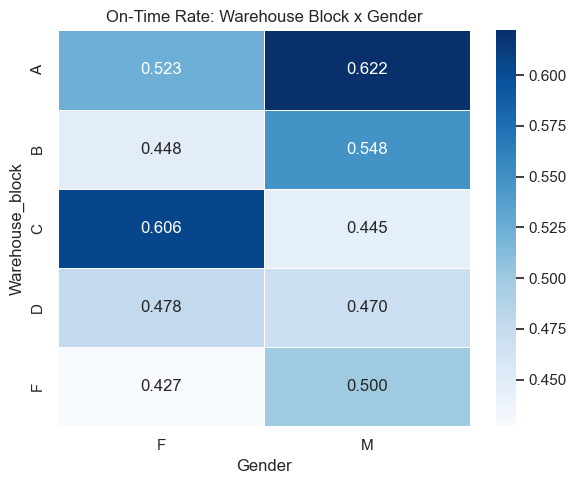

In [7]:
# Heatmap: Warehouse Block x Gender x On-Time Rate
pivot2 = df.pivot_table(
    values='Reached.on.Time_Y.N',
    index='Warehouse_block',
    columns='Gender',
    aggfunc='mean'
).round(3)

plt.figure(figsize=(6, 5))
sns.heatmap(pivot2, annot=True, cmap='Blues', fmt='.3f', linewidths=0.5)
plt.title('On-Time Rate: Warehouse Block x Gender')
plt.tight_layout()
plt.show()

In [8]:
# Drill-down: Within Warehouse F, analyze by mode and prior purchases
warehouse_f = df[df['Warehouse_block'] == 'F']
drill = warehouse_f.groupby('Mode_of_Shipment').agg(
    Count=('Reached.on.Time_Y.N', 'count'),
    On_Time_Rate=('Reached.on.Time_Y.N', 'mean'),
    Avg_Prior_Purchases=('Prior_purchases', 'mean')
).round(3)
print("Drill-down into Warehouse F:")
drill

Drill-down into Warehouse F:


,Count,On_Time_Rate,Avg_Prior_Purchases
Mode_of_Shipment,,,
Flight,73,0.452,6.068
Road,70,0.414,5.571
Ship,53,0.547,6.887


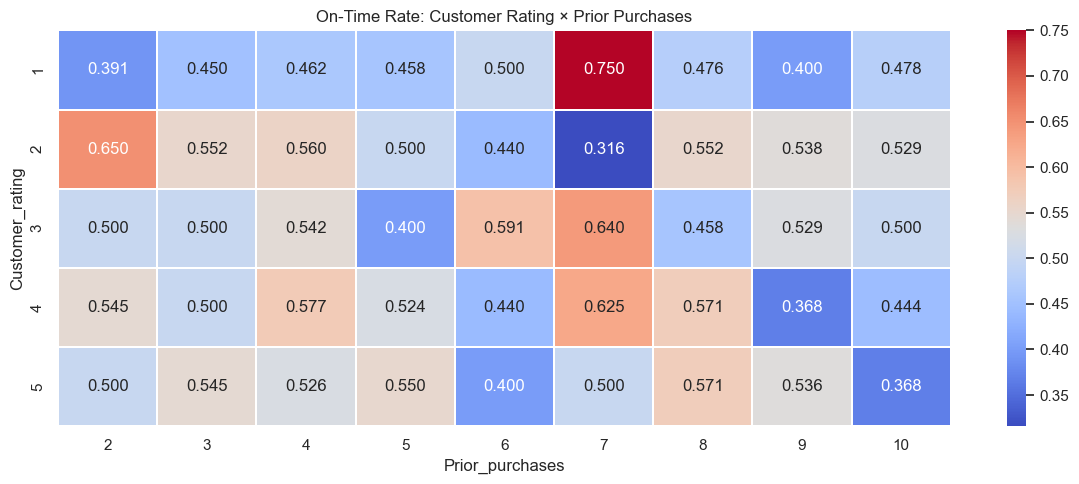

In [9]:
# Comprehensive OLAP heatmap: Rating x Prior Purchases x On-time rate
pivot3 = df.pivot_table(
    values='Reached.on.Time_Y.N',
    index='Customer_rating',
    columns='Prior_purchases',
    aggfunc='mean'
).round(3)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot3, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.title('On-Time Rate: Customer Rating × Prior Purchases')
plt.tight_layout()
plt.show()